In [2]:
import pandas as pd
import numpy as np

In [6]:
df_full = pd.read_csv("data/full_survey_data_recoded.csv")
df_full.head(20)

,QKEY,DEVICE_TYPE_W49,LANG_W49,FORM_W49,SOCMEDIAUSEa_W49,SOCMEDIAUSEb_W49,SOCMEDIAUSEc_W49,SOCMEDIAUSEd_W49,SNSUSER_W49,ELECTFTGSNSINT_W49,...,FACE3a_W49_num,FACE3b_W49_num,FACE3c_W49_num,FACE4a_W49_num,FACE4b_W49_num,FACE4c_W49_num,FACE4d_W49_num,DB1a_W49_num,DB1b_W49_num,DB1c_W49_num
0,100260.0,Tablet,English,Form 2,"No, do not use this","No, do not use this","No, do not use this","No, do not use this",Does not use social media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,100588.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","Yes, use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,100637.0,Desktop,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,2.0,1.0,1.0,NaN,NaN,1.0,0.0,0.0
3,101224.0,Mobile phone,English,Form 2,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,101322.0,Mobile phone,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
5,101437.0,Desktop,English,Form 2,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I don’t feel strongly about these posts one wa...,...,1.0,1.0,3.0,NaN,NaN,NaN,1.0,0.0,0.0,0.0
6,101472.0,Mobile phone,English,Form 1,"Yes, use this","No, do not use this","Yes, use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,1.0,1.0,2.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0
7,101493.0,Desktop,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0
8,102198.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","No, do not use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,1.0,2.0,3.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0
9,103094.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","Yes, use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,1.0


In [9]:
targets = [
    "TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num", "BENEFITGOV_W49_num",
    "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num", "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num",
    "CONCERNGRPd_W49_num", "CONCERNGRPf_W49_num", "PP5a_W49_num", "PP5b_W49_num", "PP5c_W49_num", "PP5d_W49_num", "PP5e_W49_num", "PP6a_W49_num", "PP6b_W49_num", "PP6c_W49_num", "SHARE1_W49_num", "PROFILE1_W49_num"
]

# Add 'QKEY' to the list of columns to keep
cols_to_keep = ["QKEY"] + targets

# Keep only those columns
df_targets = df_full[cols_to_keep]



        QKEY  TRACKGOV1a_W49_num  TRACKGOV1b_W49_num  CONCERNGOV_W49_num  \
0   100260.0                 0.0                 0.0                 1.0   
1   100588.0                 NaN                 NaN                 NaN   
2   100637.0                 NaN                 NaN                 NaN   
3   101224.0                 3.0                 3.0                 0.0   
4   101322.0                 NaN                 NaN                 NaN   
5   101437.0                 3.0                 1.0                 2.0   
6   101472.0                 NaN                 NaN                 NaN   
7   101493.0                 NaN                 NaN                 NaN   
8   102198.0                 NaN                 NaN                 NaN   
9   103094.0                 NaN                 NaN                 NaN   
10  103190.0                 NaN                 NaN                 NaN   
11  103379.0                 3.0                 3.0                 3.0   
12  103677.0

In [15]:
import pandas as pd

government = [
    "TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num",
    "BENEFITGOV_W49_num", "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num",
    "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num"
]

company = [
    "CONCERNGRPd_W49_num", "CONCERNGRPf_W49_num", "PP5a_W49_num",
    "PP5b_W49_num", "PP5c_W49_num", "PP5d_W49_num", "PP5e_W49_num",
    "PP6a_W49_num", "PP6b_W49_num", "PP6c_W49_num", "SHARE1_W49_num",
    "PROFILE1_W49_num"
]

# Compute Spearman correlations
corr = df_targets[government + company].corr(method='spearman')

# Extract only the government–company block
corr_block = corr.loc[company, company]

corr_block.round(2)


,CONCERNGRPd_W49_num,CONCERNGRPf_W49_num,PP5a_W49_num,PP5b_W49_num,PP5c_W49_num,PP5d_W49_num,PP5e_W49_num,PP6a_W49_num,PP6b_W49_num,PP6c_W49_num,SHARE1_W49_num,PROFILE1_W49_num
CONCERNGRPd_W49_num,1.00,0.60,-0.18,-0.12,-0.12,-0.22,-0.15,-0.15,-0.21,-0.23,0.24,0.14
CONCERNGRPf_W49_num,0.60,1.00,-0.19,-0.11,-0.13,-0.19,-0.13,-0.10,-0.17,-0.17,0.20,0.16
PP5a_W49_num,-0.18,-0.19,1.00,0.53,0.52,0.59,0.53,0.38,0.35,0.37,-0.11,-0.01
PP5b_W49_num,-0.12,-0.11,0.53,1.00,0.58,0.51,0.53,0.30,0.30,0.29,-0.09,-0.08
PP5c_W49_num,-0.12,-0.13,0.52,0.58,1.00,0.51,0.57,0.30,0.33,0.31,-0.12,-0.04
PP5d_W49_num,-0.22,-0.19,0.59,0.51,0.51,1.00,0.49,0.34,0.36,0.38,-0.12,-0.07
PP5e_W49_num,-0.15,-0.13,0.53,0.53,0.57,0.49,1.00,0.26,0.31,0.29,-0.08,-0.10
PP6a_W49_num,-0.15,-0.10,0.38,0.30,0.30,0.34,0.26,1.00,0.53,0.56,-0.10,0.08
PP6b_W49_num,-0.21,-0.17,0.35,0.30,0.33,0.36,0.31,0.53,1.00,0.56,-0.14,0.02
PP6c_W49_num,-0.23,-0.17,0.37,0.29,0.31,0.38,0.29,0.56,0.56,1.00,-0.15,0.02


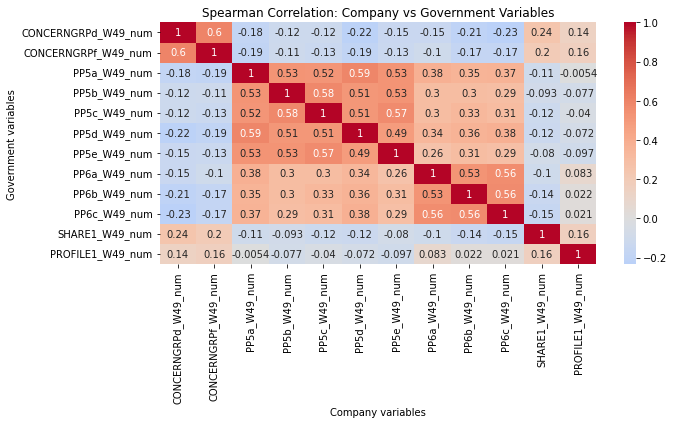

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(corr_block, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation: Company vs Government Variables")
plt.xlabel("Company variables")
plt.ylabel("Government variables")
plt.tight_layout()
plt.show()
